14:16:03 - cmdstanpy - INFO - Chain [1] start processing
14:16:04 - cmdstanpy - INFO - Chain [1] done processing


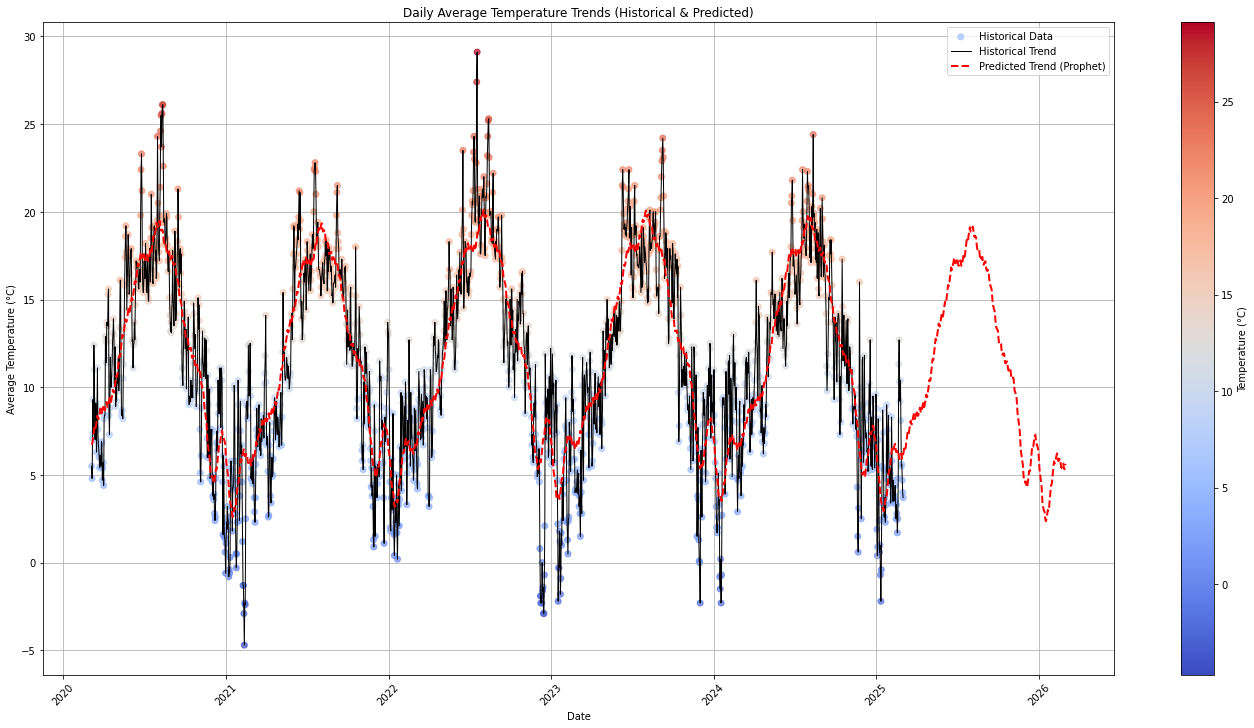

In [2]:
import requests
import json
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
from datetime import datetime, timedelta
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy.stats import zscore
import streamlit as st
from prophet import Prophet

def fetch_historical_weather_data(latitude, longitude, start_date, end_date):
    """
    Fetches historical weather data using Open-Meteo's historical API.
    """
    api_url = f"https://archive-api.open-meteo.com/v1/archive?latitude={latitude}&longitude={longitude}&daily=temperature_2m_mean&start_date={start_date.strftime('%Y-%m-%d')}&end_date={end_date.strftime('%Y-%m-%d')}&timezone=GMT"
    
    response = requests.get(api_url)
    if response.status_code == 200:
        return response.json()
    else:
        print(f"Error: {response.status_code}, {response.text}")
        return None

def process_weather_data(data):
    """
    Extracts relevant information for daily average temperatures.
    """
    weather_records = []
    
    if not isinstance(data, dict) or "daily" not in data:
        print("Error: Unexpected API response format.")
        return weather_records
    
    daily_data = data["daily"]
    if "time" not in daily_data or "temperature_2m_mean" not in daily_data:
        print("Error: Missing expected keys in daily data.")
        return weather_records
    
    timestamps = daily_data["time"]
    temperatures = daily_data["temperature_2m_mean"]
    
    for i in range(len(timestamps)):
        try:
            record_date = datetime.strptime(timestamps[i], "%Y-%m-%d").date()
            
            weather_records.append({
                "Date": record_date,
                "Average Temperature (°C)": temperatures[i],
            })
        except Exception as e:
            print(f"Skipping invalid record at index {i}: {e}")
            continue
    
    return pd.DataFrame(weather_records)  # Convert list to DataFrame before returning

def predict_future_temperatures(data, days=365):
    """
    Uses Prophet to predict future temperatures.
    """
    df = pd.DataFrame(data).copy()  # Explicitly create a copy to avoid SettingWithCopyWarning
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df.rename(columns={'Date': 'ds', 'Average Temperature (°C)': 'y'}, inplace=True)
    
    # Handle missing values
    df.dropna(subset=['y'], inplace=True)
    
    if df.empty:
        print("Error: No valid temperature data available for prediction.")
        return pd.DataFrame()
    
    # Fit Prophet model
    model = Prophet()
    model.fit(df)
    
    # Create future dataframe
    future = model.make_future_dataframe(periods=days)
    forecast = model.predict(future)
    
    future_df = forecast[['ds', 'yhat']].copy()
    future_df.rename(columns={'ds': 'Date', 'yhat': 'Predicted Temperature (°C)'}, inplace=True)
    
    return future_df

def visualize_weather_patterns(data, future_predictions=None):
    """
    Visualizes historical and predicted weather patterns with trendlines.
    """
    if data.empty:
        print("No data available for visualization.")
        return
    
    df = pd.DataFrame(data)
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df.dropna(subset=['Date'], inplace=True)
    
    # Create color gradient based on temperature
    norm = mcolors.Normalize(vmin=df['Average Temperature (°C)'].min(), vmax=df['Average Temperature (°C)'].max())
    cmap = plt.colormaps.get_cmap('coolwarm')
    colors = [cmap(norm(temp)) for temp in df['Average Temperature (°C)']]
    
    fig, ax = plt.subplots(figsize=(24, 12))
    scatter = ax.scatter(df['Date'], df['Average Temperature (°C)'], color=colors, label='Historical Data', alpha=0.7)
    ax.plot(df['Date'], df['Average Temperature (°C)'], color='black', linestyle='-', linewidth=1, label='Historical Trend')
    
    # Plot future predictions if available
    if future_predictions is not None and not future_predictions.empty:
        future_df = pd.DataFrame(future_predictions)
        future_df['Date'] = pd.to_datetime(future_df['Date'], errors='coerce')
        ax.plot(future_df['Date'], future_df['Predicted Temperature (°C)'], color='red', linestyle='dashed', linewidth=2, label='Predicted Trend (Prophet)')
    
    ax.set_xlabel('Date')
    ax.set_ylabel('Average Temperature (°C)')
    ax.set_title('Daily Average Temperature Trends (Historical & Predicted)')
    ax.tick_params(axis='x', rotation=45)
    fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label='Temperature (°C)')
    ax.legend()
    ax.grid()
    plt.show()

if __name__ == "__main__":
    latitude = 51.509865
    longitude = -0.118092
    end_date = datetime.today().date()
    start_date = end_date - timedelta(days=5*365)
    
    raw_data = fetch_historical_weather_data(latitude, longitude, start_date, end_date)
    
    if raw_data:
        processed_data = process_weather_data(raw_data)
        future_predictions = predict_future_temperatures(processed_data)
        visualize_weather_patterns(processed_data, future_predictions)
    else:
        print("Failed to retrieve valid data.")